In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Choose which simulations to plot (one figure per simulation)
simulations = ["curve", "deflection", "ridges", "branching", "edge"]
models = ["dfNN", "dfGP", "dfGPcm", "dfNGP", "PINN", "GP"]

MEAN_ROW_IDX = 0
STD_ROW_IDX = 1

# SIM RMSE

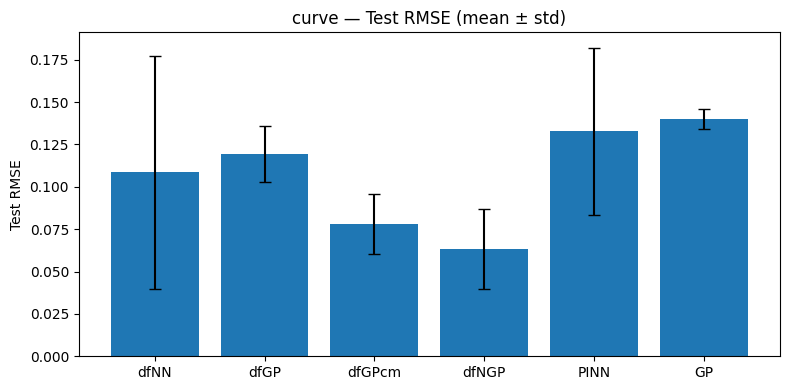

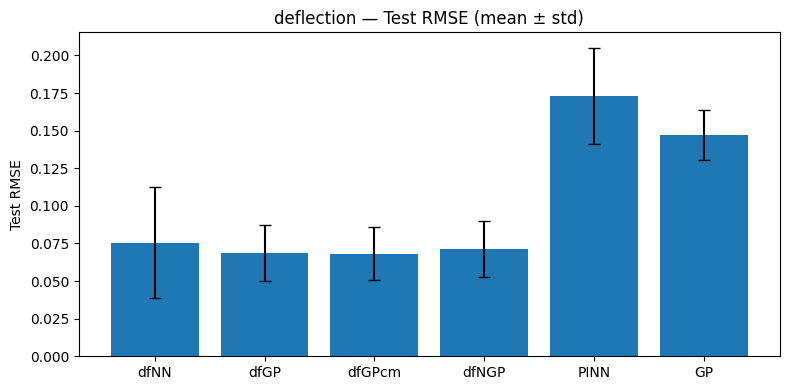

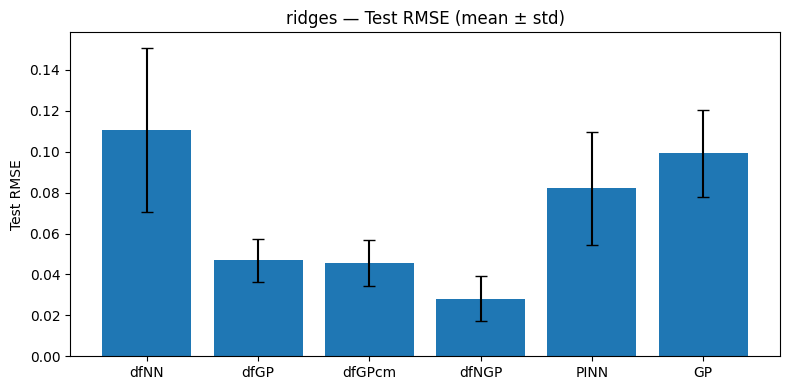

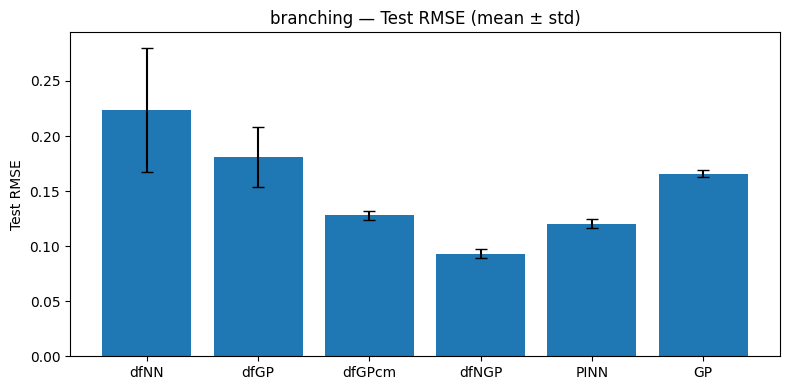

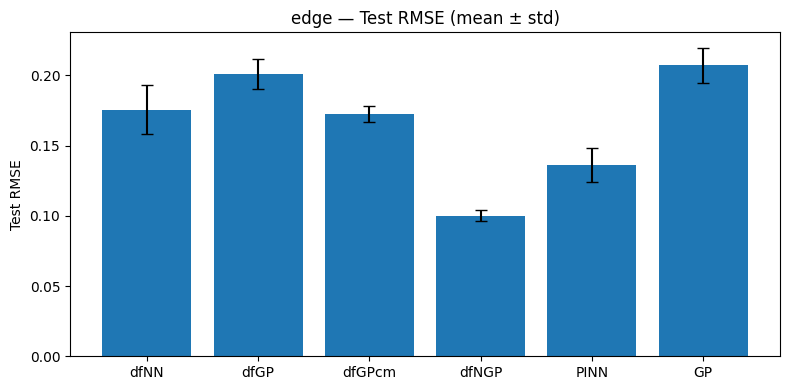

In [ ]:
# If your CSVs put mean in row 0 and std in row 1 (same column name), set these:
METRIC_COL = "Test RMSE"

for sim in simulations:
    rows = []
    for m in models:
        path = os.path.join(m, f"{sim}_{m}_metrics_summary.csv")
        if not os.path.exists(path):
            # skip missing results gracefully
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path)
        mean_rmse = df[METRIC_COL].iloc[MEAN_ROW_IDX]
        std_rmse  = df[METRIC_COL].iloc[STD_ROW_IDX]
        rows.append({"model": m, "mean": mean_rmse, "std": std_rmse})

    if not rows:
        continue

    plot_df = pd.DataFrame(rows).set_index("model").loc[models]  # keep consistent order

    # --- Bar chart with error bars ---
    plt.figure(figsize=(8, 4))
    x = np.arange(len(plot_df))
    plt.bar(x, plot_df["mean"], yerr=plot_df["std"], capsize=4)
    plt.xticks(x, plot_df.index, rotation=0)
    plt.ylabel("Test RMSE")
    plt.title(f"{sim} — Test RMSE (mean ± std)")
    plt.tight_layout()
    plt.show()

# Produce barplot for paper

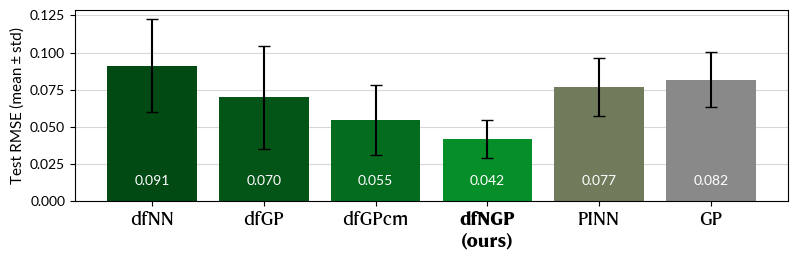

In [70]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import matplotlib as mpl
from matplotlib import font_manager as fm
fm.fontManager.addfont('/home/kim/underPINNed/fonts/Lato-Regular.ttf')
fm.fontManager.addfont('/home/kim/underPINNed/fonts/Harding Text Web Regular Regular.ttf')
# fm.fontManager.addfont('/path/to/Lato-Bold.ttf')
mpl.rcParams['font.family'] = 'Lato'

harding = fm.FontProperties(
    fname = "/home/kim/underPINNed/fonts/Harding Text Web Regular Regular.ttf",
    size = 9
)

harding_bold = fm.FontProperties(
    fname = "/home/kim/underPINNed/fonts/Harding Text Web Bold Regular.ttf",
    size = 9
)

simulations = ["curve", "deflection", "ridges", "branching", "edge"]
# order from paper
models = ["dfNN", "dfGP", "dfGPcm", "dfNGP", "PINN", "GP"]

model_colors = {
    "dfNN": "#014A13", 
    "dfGP": "#035417",  
    "dfGPcm": "#046c1e", 
    "dfNGP": "#068e28", 
    "PINN": "#6f7b5a", 
    "GP": "#898989", 
}

METRIC_COL = "Test RMSE"

# Collect per-simulation means for each model
per_model_sim_means = {m: [] for m in models}

for sim in simulations:
    for m in models:
        path = os.path.join(m, f"{sim}_{m}_metrics_summary.csv")
        if not os.path.exists(path):
            print(f"Missing: {path}")
            continue

        df = pd.read_csv(path)

        # If each CSV has raw per-run rows, use mean() across runs:
        sim_mean = df[METRIC_COL].mean()

        # If instead your CSV has two rows (mean, std), use:
        # sim_mean = df[METRIC_COL].iloc[0]

        per_model_sim_means[m].append(sim_mean)

# Build overall summary: mean across simulations (+ std across simulations)
rows = []
for m in models:
    vals = per_model_sim_means[m]
    if len(vals) == 0:
        continue
    overall_mean = float(np.mean(vals))
    overall_std  = float(np.std(vals, ddof=1))  # std across simulations
    rows.append({"model": m, "mean": overall_mean, "std": overall_std})

summary = pd.DataFrame(rows).set_index("model").loc[[m for m in models if m in [r["model"] for r in rows]]]

# --- Single bar chart: mean across 5 simulations (error = std across simulations) ---
fig, ax = plt.subplots(figsize = (8, 2.7))

x = np.arange(len(summary))

ax.bar(
    x,
    summary["mean"],
    yerr = summary["std"],
    capsize = 4,
    color = [model_colors[m] for m in summary.index],
)

# add values inside bars (bottom, white, Lato font)
for xpos, val in zip(x, summary["mean"]):
    ax.text(
        xpos,                    # x position
        0.01,                    # y position (a bit above 0, adjust if needed)
        f"{val:.3f}",            # format to 3 decimals
        ha = "center", va = "bottom",
        color = "white",
        fontproperties = "Lato",
        fontsize = 10
    )

# grid behind bars
ax.grid(axis = "y", linestyle = "-", linewidth = 0.8, alpha = 0.5)
ax.set_axisbelow(True)

# labels
ax.set_xticks(x)

labels = [m if m != "dfNGP" else "dfNGP\n(ours)" for m in summary.index]

# set tick labels first
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontproperties = harding, fontsize = 13)
ax.set_ylabel("Test RMSE (mean ± std)", fontproperties = "lato", fontsize = 11)

# now adjust dfNGP label only
for label, model in zip(ax.get_xticklabels(), summary.index):
    if model == "dfNGP":
        label.set_fontproperties(harding_bold)
        label.set_fontsize(13)  # bold font

fig.tight_layout()
fig.savefig("rmse_barplot.png", dpi = 300)
plt.show()

# SIM NLL

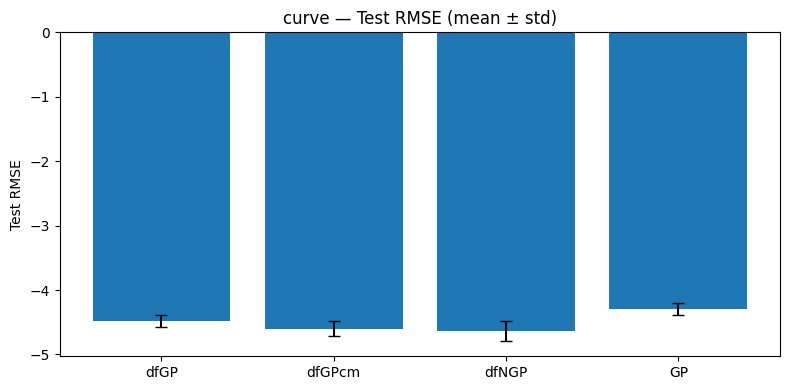

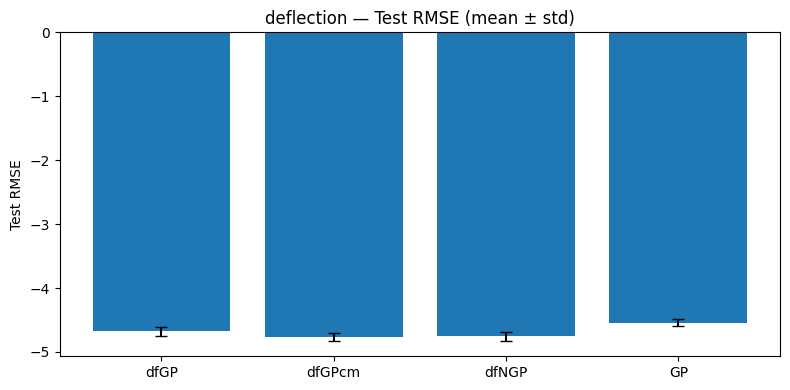

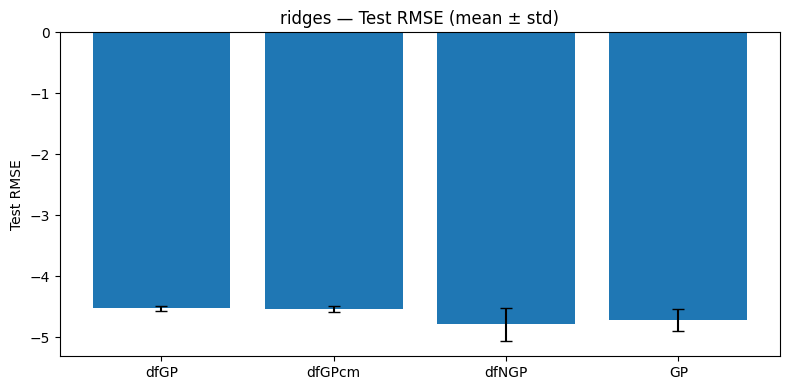

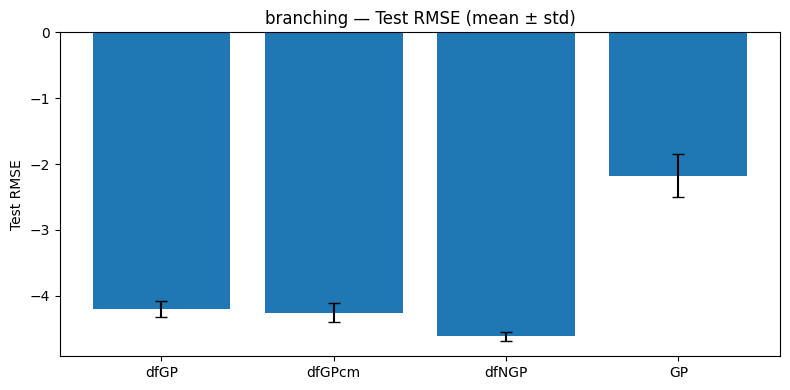

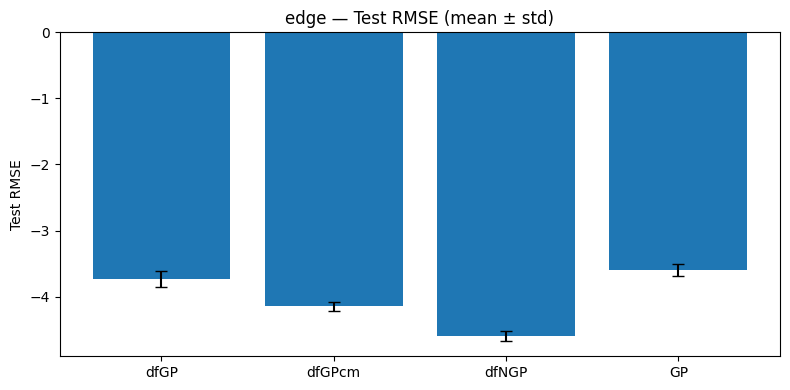

In [14]:
# If your CSVs put mean in row 0 and std in row 1 (same column name), set these:
METRIC_COL = "Test NLL"

# Only for probabilistic models
models = ["dfGP", "dfGPcm", "dfNGP", "GP"]

for sim in simulations:
    rows = []
    for m in models:
        path = os.path.join(m, f"{sim}_{m}_metrics_summary.csv")
        if not os.path.exists(path):
            # skip missing results gracefully
            print(f"Missing: {path}")
            continue
        df = pd.read_csv(path)
        mean_rmse = df[METRIC_COL].iloc[MEAN_ROW_IDX]
        std_rmse  = df[METRIC_COL].iloc[STD_ROW_IDX]
        rows.append({"model": m, "mean": mean_rmse, "std": std_rmse})

    if not rows:
        continue

    plot_df = pd.DataFrame(rows).set_index("model").loc[models]  # keep consistent order

    # --- Bar chart with error bars ---
    plt.figure(figsize=(8, 4))
    x = np.arange(len(plot_df))
    plt.bar(x, plot_df["mean"], yerr=plot_df["std"], capsize=4)
    plt.xticks(x, plot_df.index, rotation=0)
    plt.ylabel("Test RMSE")
    plt.title(f"{sim} — Test RMSE (mean ± std)")
    plt.tight_layout()
    plt.show()
